In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler
from torch.utils.data import random_split
from torch.utils.data import Subset
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
from sklearn.model_selection import train_test_split



In [2]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

data_augmentation = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [3]:
data_dir = ".."
full_train = datasets.OxfordIIITPet(root=data_dir,split="trainval", transform=data_transform, download=False, target_types="category")
test = datasets.OxfordIIITPet(root=data_dir,split="test", transform=data_transform, download=False, target_types="category")


In [ ]:
class_names = full_train.classes

def get_limited_dataloaders(train_dataset, fraction, batch_size=4):
    if fraction == 1.0:
            return DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    labels = [train_dataset.dataset._labels[i] for i in train_dataset.indices]
    selected, _ = train_test_split(train_dataset.indices, train_size=fraction, stratify=labels)
    limited_data = Subset(train_dataset.dataset, selected)
    return DataLoader(limited_data, batch_size=batch_size, shuffle=True, num_workers=0)


train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train, val = random_split(full_train, [train_size, val_size])

full_train_aug = datasets.OxfordIIITPet(root=data_dir,split="trainval", transform=data_augmentation, download=False, target_types="category")
train_aug = Subset(full_train_aug, train.indices)

val_loader = DataLoader(val, batch_size=4, shuffle=False, num_workers=0)
test_loader = DataLoader(test, batch_size=4, shuffle=False, num_workers=0)


dataloaders = []

fractions = [0.05, 0.1]
for frac in fractions:
    train_loader = get_limited_dataloaders(train_aug, frac)
    dataloaders.append({"train": train_loader, "val": val_loader, "test": test_loader})



In [11]:
dataloaders_no_aug = []
for frac in fractions:
    train_loader_no_aug = get_limited_dataloaders(train, frac)
    dataloaders_no_aug.append({"train": train_loader_no_aug, "val": val_loader, "test": test_loader})

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device}")

Using cuda


In [7]:
def evaluate_dataset(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device); labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
    total = len(dataloader.dataset)
    return running_loss / total, (running_corrects.double().item() / total)

In [8]:
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch+1}/{num_epochs}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()


                epoch_loss = running_loss / len(dataloaders[phase].dataset)
                epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            train_loss_final, train_acc_final = evaluate_dataset(model, dataloaders['train'], criterion)
            val_loss_final, val_acc_final     = evaluate_dataset(model, dataloaders['val'],   criterion)

            train_loss_history.append(train_loss_final)
            train_acc_history.append(train_acc_final)
            val_loss_history.append(val_loss_final)
            val_acc_history.append(val_acc_final)
            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model, train_loss_history, val_loss_history, train_acc_history, val_acc_history

In [9]:
def get_model():
    model = models.resnet34(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = False
    model.fc = torch.nn.Linear(in_features=512, out_features=37)
    return model.to(device)

model = get_model()

criterion = torch.nn.CrossEntropyLoss()

optimizer_ft = optim.Adam(model.fc.parameters(), lr=0.001)

In [14]:
results = []
results_aug = []

fractions = [0.05, 0.1]

for i, fraction in enumerate(fractions):
    print(f"Training with {int(fraction*100)}% of the training data")
    model = get_model() 
    optimizer_ft = optim.Adam(model.fc.parameters(), lr=0.001)
    scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)
    dataloader = dataloaders[i]
    model, train_loss_history, val_loss_history, train_acc_history, val_acc_history = train_model(model, dataloader, criterion, optimizer_ft, scheduler, num_epochs=25)

    results_aug.append((fraction, train_loss_history, val_loss_history, train_acc_history, val_acc_history))


for i, fraction in enumerate(fractions):
    print(f"Training with {int(fraction*100)}% of the training data")
    model = get_model() 
    optimizer_ft = optim.Adam(model.fc.parameters(), lr=0.001)
    scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)
    dataloader = dataloaders_no_aug[i]
    model, train_loss_history, val_loss_history, train_acc_history, val_acc_history = train_model(model, dataloader, criterion, optimizer_ft, scheduler, num_epochs=25)

    results.append((fraction, train_loss_history, val_loss_history, train_acc_history, val_acc_history))




Training with 5% of the training data
Epoch 1/25
----------
train Loss: 4.6470 Acc: 0.0136
val Loss: 3.3843 Acc: 0.1209

Epoch 2/25
----------
train Loss: 3.2322 Acc: 0.1293
val Loss: 2.6081 Acc: 0.3315

Epoch 3/25
----------
train Loss: 2.6575 Acc: 0.3469
val Loss: 2.2098 Acc: 0.4891

Epoch 4/25
----------
train Loss: 2.1983 Acc: 0.4694
val Loss: 1.8552 Acc: 0.5734

Epoch 5/25
----------
train Loss: 1.9022 Acc: 0.5986
val Loss: 1.6122 Acc: 0.6508

Epoch 6/25
----------
train Loss: 1.4863 Acc: 0.7687
val Loss: 1.4908 Acc: 0.6250

Epoch 7/25
----------
train Loss: 1.3649 Acc: 0.7483
val Loss: 1.2913 Acc: 0.6861

Epoch 8/25
----------
train Loss: 1.0803 Acc: 0.8844
val Loss: 1.2749 Acc: 0.6929

Epoch 9/25
----------
train Loss: 0.9920 Acc: 0.9320
val Loss: 1.2473 Acc: 0.7106

Epoch 10/25
----------
train Loss: 0.9912 Acc: 0.9456
val Loss: 1.2138 Acc: 0.7215

Epoch 11/25
----------
train Loss: 1.0555 Acc: 0.9184
val Loss: 1.2060 Acc: 0.7174

Epoch 12/25
----------
train Loss: 0.9273 Acc: 

In [15]:
l2 = 1e-3

results_aug_l2 = []
for i, fraction in enumerate(fractions):
    print(f"Training with {int(fraction*100)}% of the training data and data augmentation")
    model = get_model() 
    optimizer_ft = optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=l2)
    scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)
    dataloader = dataloaders[i]
    model, train_loss_history, val_loss_history, train_acc_history, val_acc_history = train_model(model, dataloader, criterion, optimizer_ft, scheduler, num_epochs=25)

    results_aug_l2.append((fraction, train_loss_history, val_loss_history, train_acc_history, val_acc_history))


Training with 5% of the training data and data augmentation
Epoch 1/25
----------
train Loss: 4.4581 Acc: 0.0136
val Loss: 3.1740 Acc: 0.1481

Epoch 2/25
----------
train Loss: 3.1663 Acc: 0.1633
val Loss: 2.6522 Acc: 0.3302

Epoch 3/25
----------
train Loss: 2.6783 Acc: 0.3265
val Loss: 2.0946 Acc: 0.5245

Epoch 4/25
----------
train Loss: 2.1095 Acc: 0.5646
val Loss: 1.8191 Acc: 0.5747

Epoch 5/25
----------
train Loss: 1.8998 Acc: 0.6259
val Loss: 1.5627 Acc: 0.6209

Epoch 6/25
----------
train Loss: 1.5994 Acc: 0.6395
val Loss: 1.3906 Acc: 0.6603

Epoch 7/25
----------
train Loss: 1.3702 Acc: 0.7687
val Loss: 1.3043 Acc: 0.6875

Epoch 8/25
----------
train Loss: 1.0966 Acc: 0.8571
val Loss: 1.2114 Acc: 0.7092

Epoch 9/25
----------
train Loss: 0.9786 Acc: 0.9116
val Loss: 1.1737 Acc: 0.7092

Epoch 10/25
----------
train Loss: 0.9688 Acc: 0.9320
val Loss: 1.1860 Acc: 0.7120

Epoch 11/25
----------
train Loss: 0.9813 Acc: 0.9456
val Loss: 1.1778 Acc: 0.7215

Epoch 12/25
----------
tr

In [19]:
l2 = 1e-3

results_no_aug_l2 = []
for i, fraction in enumerate(fractions):
    print(f"Training with {int(fraction*100)}% of the training data and data augmentation")
    model = get_model() 
    optimizer_ft = optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=l2)
    scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)
    dataloader = dataloaders_no_aug[i]
    model, train_loss_history, val_loss_history, train_acc_history, val_acc_history = train_model(model, dataloader, criterion, optimizer_ft, scheduler, num_epochs=25)

    results_no_aug_l2.append((fraction, train_loss_history, val_loss_history, train_acc_history, val_acc_history))


Training with 5% of the training data and data augmentation
Epoch 1/25
----------
train Loss: 4.5372 Acc: 0.0204
val Loss: 3.2346 Acc: 0.1603

Epoch 2/25
----------
train Loss: 3.1109 Acc: 0.1837
val Loss: 2.6148 Acc: 0.3587

Epoch 3/25
----------
train Loss: 2.5913 Acc: 0.3129
val Loss: 2.2013 Acc: 0.4620

Epoch 4/25
----------
train Loss: 2.0564 Acc: 0.5918
val Loss: 1.7965 Acc: 0.6128

Epoch 5/25
----------
train Loss: 1.6361 Acc: 0.7483
val Loss: 1.6491 Acc: 0.6019

Epoch 6/25
----------
train Loss: 1.3527 Acc: 0.7891
val Loss: 1.3996 Acc: 0.6821

Epoch 7/25
----------
train Loss: 1.0968 Acc: 0.8503
val Loss: 1.2872 Acc: 0.6916

Epoch 8/25
----------
train Loss: 0.8475 Acc: 0.9320
val Loss: 1.2614 Acc: 0.6957

Epoch 9/25
----------
train Loss: 0.7746 Acc: 0.9660
val Loss: 1.2235 Acc: 0.7065

Epoch 10/25
----------
train Loss: 0.7910 Acc: 0.9524
val Loss: 1.2400 Acc: 0.6984

Epoch 11/25
----------
train Loss: 0.7852 Acc: 0.9592
val Loss: 1.1800 Acc: 0.7215

Epoch 12/25
----------
tr

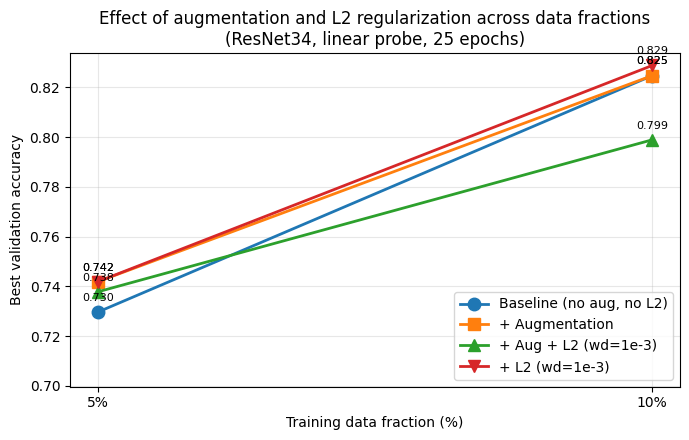

In [20]:
import matplotlib.pyplot as plt

def best_val_acc(results, fraction, atol=1e-6):
    """Récupère la meilleure val_acc pour une fraction donnée."""
    for entry in results:
        if abs(entry[0] - fraction) < atol:
            return max(entry[4])  # entry[4] = val_acc_history
    return None

# Configurations à comparer (toutes à 25 epochs, linear probe)
configs = [
    ("Baseline (no aug, no L2)", results,        [0.05, 0.10], "#1f77b4", "o"),
    ("+ Augmentation",           results_aug,    [0.05, 0.10], "#ff7f0e", "s"),
    ("+ Aug + L2 (wd=1e-3)",     results_aug_l2, [0.05, 0.10],       "#2ca02c", "^"),
    ("+ L2 (wd=1e-3)",          results_no_aug_l2, [0.05, 0.10], "#d62728", "v"),
]

fig, ax = plt.subplots(figsize=(7, 4.5))

for label, res, fracs, color, marker in configs:
    xs = [f * 100 for f in fracs]
    ys = [best_val_acc(res, f) for f in fracs]
    ax.plot(xs, ys, marker=marker, markersize=9, linewidth=2,
            label=label, color=color)
    # annotation des valeurs
    for x, y in zip(xs, ys):
        if y is not None:
            ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=8)

ax.set_xlabel("Training data fraction (%)")
ax.set_ylabel("Best validation accuracy")
ax.set_title("Effect of augmentation and L2 regularization across data fractions\n"
             "(ResNet34, linear probe, 25 epochs)")
ax.set_xticks([5, 10])
ax.set_xticklabels(["5%", "10%"])
ax.grid(alpha=0.3)
ax.legend(loc="lower right", frameon=True)
ax.set_ylim(bottom=min(y for _, res, fracs, _, _ in configs
                       for y in [best_val_acc(res, f) for f in fracs] if y) - 0.03)

plt.tight_layout()
plt.savefig("synthesis_aug_l2.png", dpi=150, bbox_inches="tight")
plt.show()

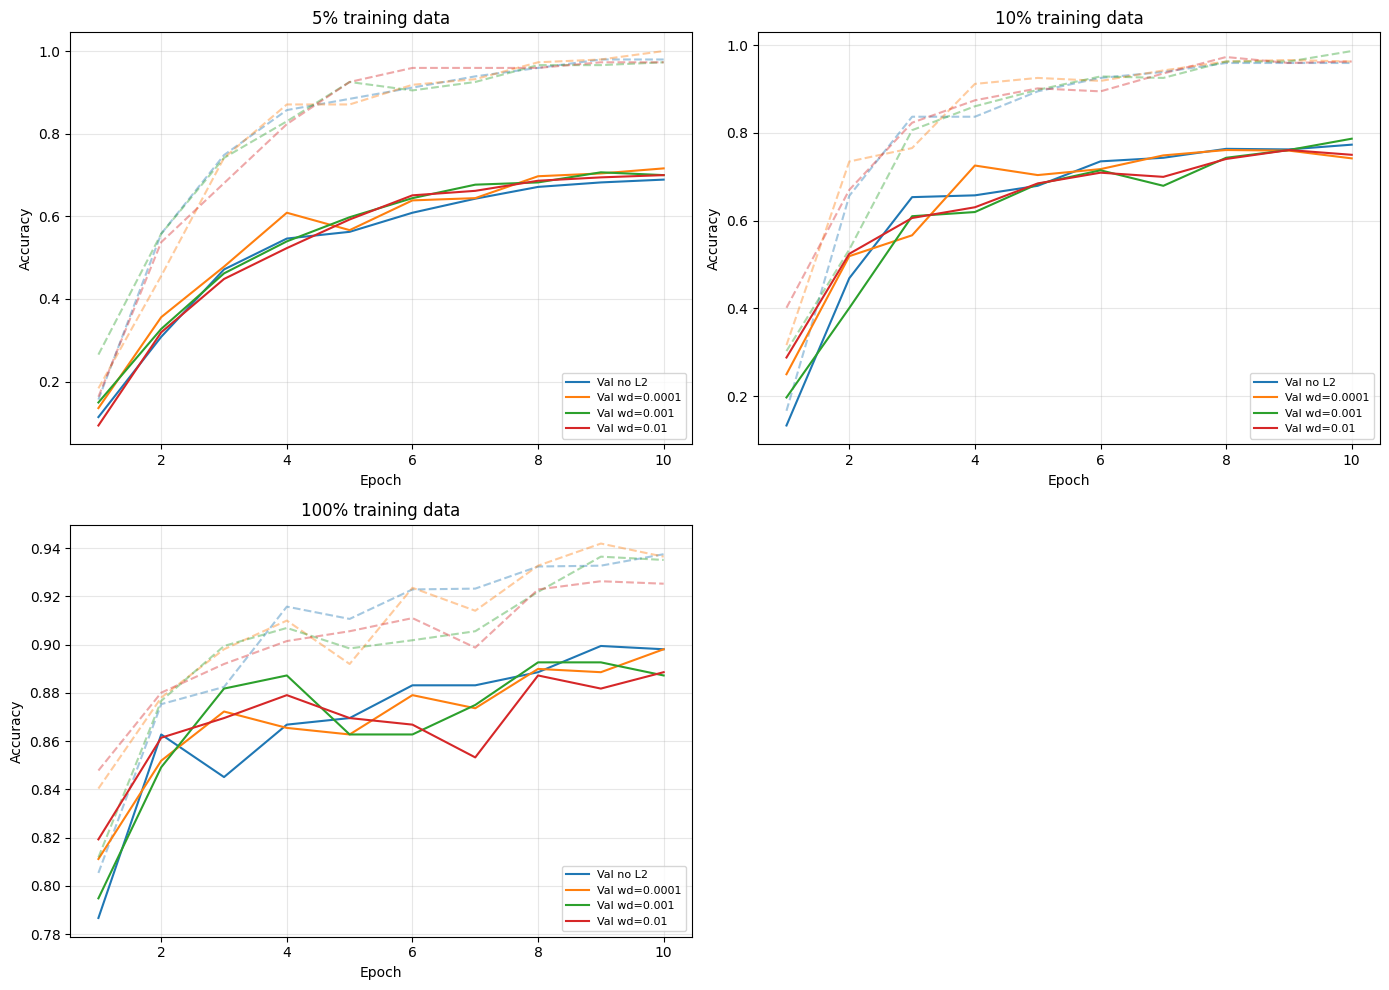

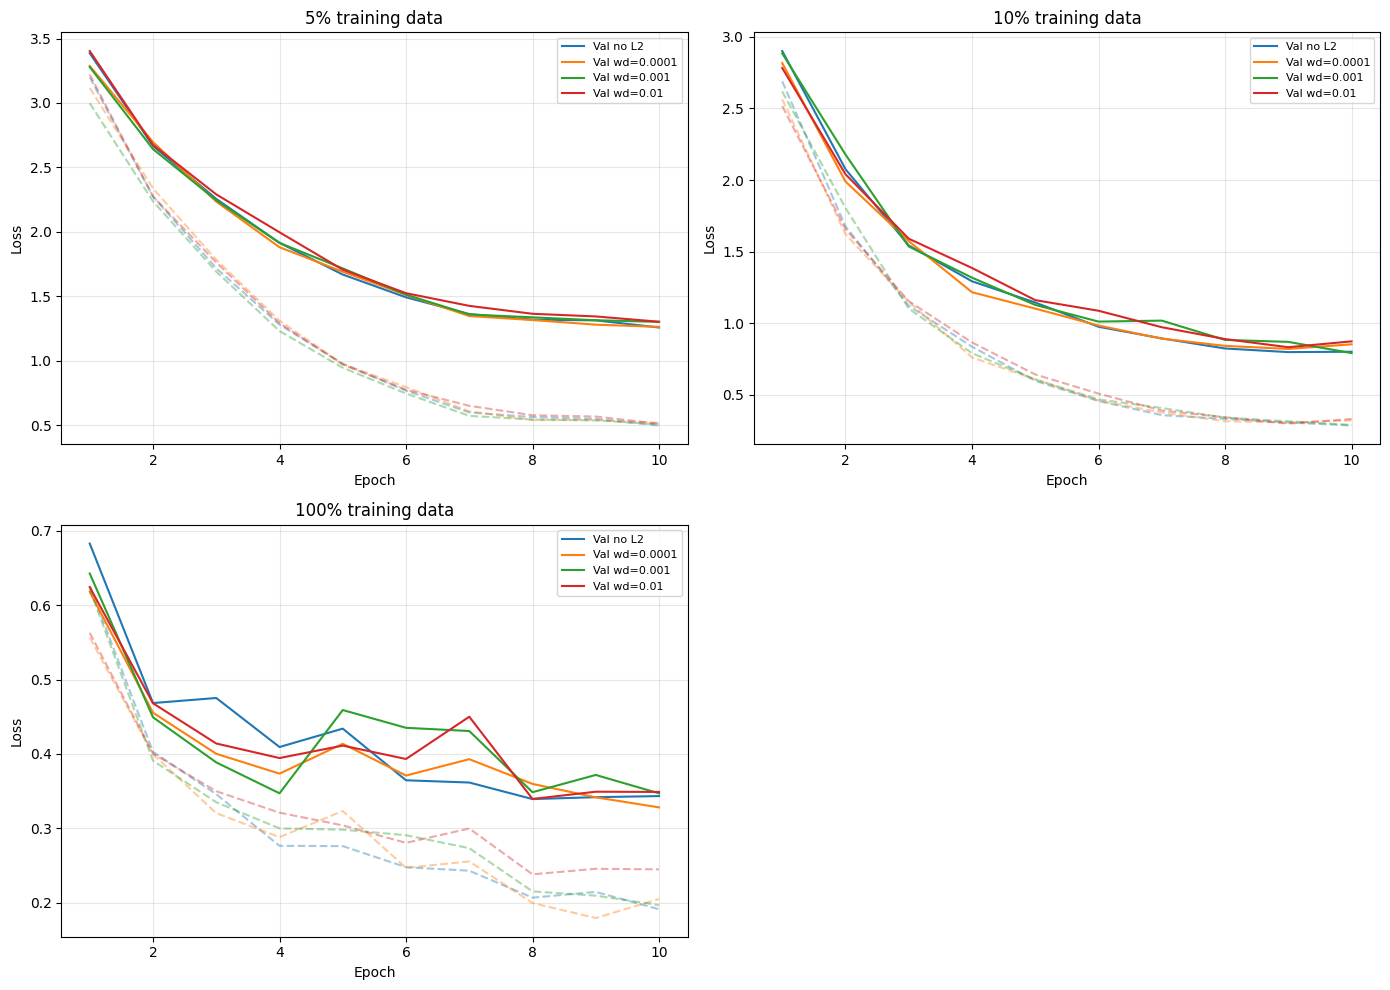

In [ ]:
fractions_unique = sorted(set(r[0] for r in results_l2))
wds_unique = sorted(set(r[5] for r in results_l2))

# Val accuracy per fraction
ncols = 2
nrows = (len(fractions_unique) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes = axes.flatten()

for ax, frac in zip(axes, fractions_unique):
    for wd in wds_unique:
        run = next(r for r in results_l2 if r[0] == frac and r[5] == wd)
        _, _, _, train_acc, val_acc, _ = run
        epochs = range(1, len(val_acc) + 1)
        label = 'no L2' if wd == 0 else f'wd={wd:g}'
        line, = ax.plot(epochs, val_acc, linestyle='-', label=f'Val {label}')
        ax.plot(epochs, train_acc, linestyle='--', alpha=0.4, color=line.get_color())
    ax.set_title(f'{int(frac*100)}% training data')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')

for ax in axes[len(fractions_unique):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('../results_limited_data/l2_accuracy_per_fraction.png', dpi=150)
plt.show()

# Val loss per fraction
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes = axes.flatten()

for ax, frac in zip(axes, fractions_unique):
    for wd in wds_unique:
        run = next(r for r in results_l2 if r[0] == frac and r[5] == wd)
        _, train_loss, val_loss, _, _, _ = run
        epochs = range(1, len(val_loss) + 1)
        label = 'no L2' if wd == 0 else f'wd={wd:g}'
        line, = ax.plot(epochs, val_loss, linestyle='-', label=f'Val {label}')
        ax.plot(epochs, train_loss, linestyle='--', alpha=0.4, color=line.get_color())
    ax.set_title(f'{int(frac*100)}% training data')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(fractions_unique):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('../results_limited_data/l2_loss_per_fraction.png', dpi=150)
plt.show()

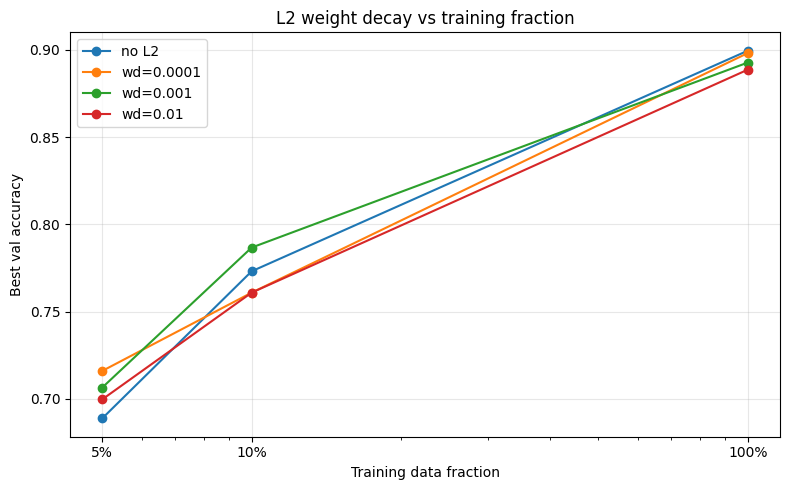

In [ ]:
plt.figure(figsize=(8, 5))
fracs_x = [int(f * 100) for f in fractions_unique]
for wd in wds_unique:
    best = [max(next(r for r in results_l2 if r[0] == f and r[5] == wd)[4])
            for f in fractions_unique]
    label = 'no L2' if wd == 0 else f'wd={wd:g}'
    plt.plot(fracs_x, best, marker='o', label=label)
plt.xscale('log')
plt.xticks(fracs_x, [f'{p}%' for p in fracs_x])
plt.xlabel('Training data fraction')
plt.ylabel('Best val accuracy')
plt.title('L2 weight decay vs training fraction')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../results_limited_data/l2_best_val_acc.png', dpi=150)
plt.show()

In [ ]:
results_l2_base = []

for i, fraction in enumerate(fractions):
    print(f"Training with {int(fraction*100)}% of the training data")
    for wd in weight_decays:
        model = get_model() 
        optimizer_ft = optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=wd)
        scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)
        dataloader = dataloaders_no_aug[i]
        model, train_loss_history, val_loss_history, train_acc_history, val_acc_history = train_model(model, dataloader, criterion, optimizer_ft, scheduler, num_epochs=10)

        results_l2_base.append((fraction, train_loss_history, val_loss_history, train_acc_history, val_acc_history, wd))

Training with 5% of the training data
Epoch 1/10
----------
train Loss: 4.4452 Acc: 0.0000
val Loss: 3.3623 Acc: 0.1033

Epoch 2/10
----------
train Loss: 3.1247 Acc: 0.1837
val Loss: 2.6474 Acc: 0.3438

Epoch 3/10
----------
train Loss: 2.4204 Acc: 0.4286
val Loss: 2.2240 Acc: 0.4660

Epoch 4/10
----------
train Loss: 1.9618 Acc: 0.6463
val Loss: 1.8594 Acc: 0.5679

Epoch 5/10
----------
train Loss: 1.5709 Acc: 0.7755
val Loss: 1.5838 Acc: 0.6617

Epoch 6/10
----------
train Loss: 1.2666 Acc: 0.8231
val Loss: 1.4251 Acc: 0.6522

Epoch 7/10
----------
train Loss: 1.0659 Acc: 0.8707
val Loss: 1.2672 Acc: 0.6916

Epoch 8/10
----------
train Loss: 0.8670 Acc: 0.9116
val Loss: 1.2777 Acc: 0.6916

Epoch 9/10
----------
train Loss: 0.8182 Acc: 0.9320
val Loss: 1.1986 Acc: 0.7106

Epoch 10/10
----------
train Loss: 0.7772 Acc: 0.9660
val Loss: 1.2034 Acc: 0.7160

Training complete in 3m 41s
Best val Acc: 0.716033
Epoch 1/10
----------
train Loss: 4.4603 Acc: 0.0272
val Loss: 3.3146 Acc: 0.125

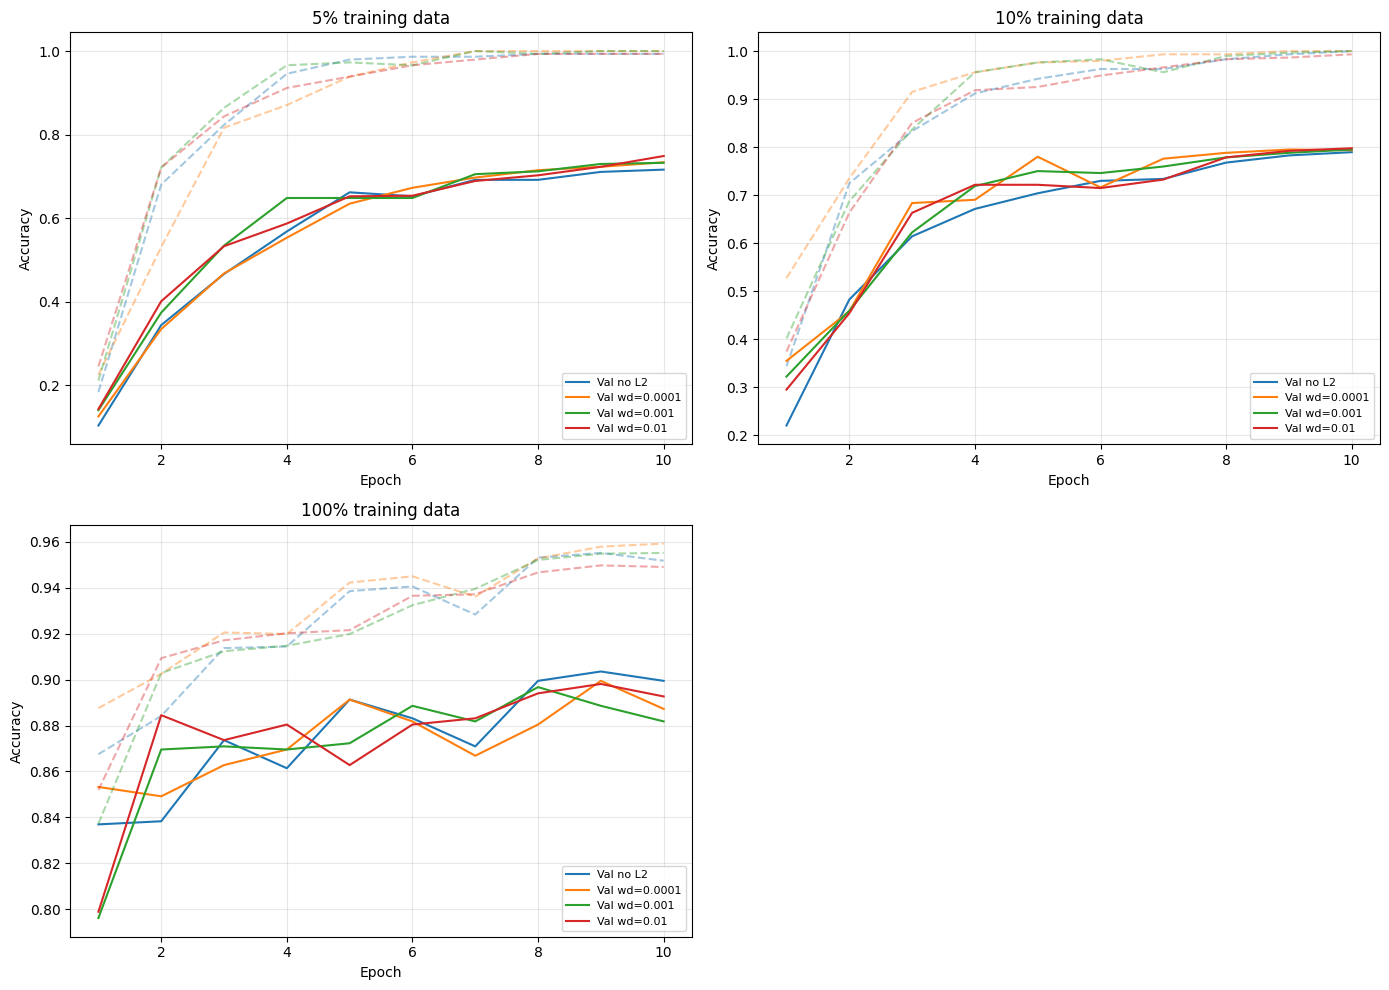

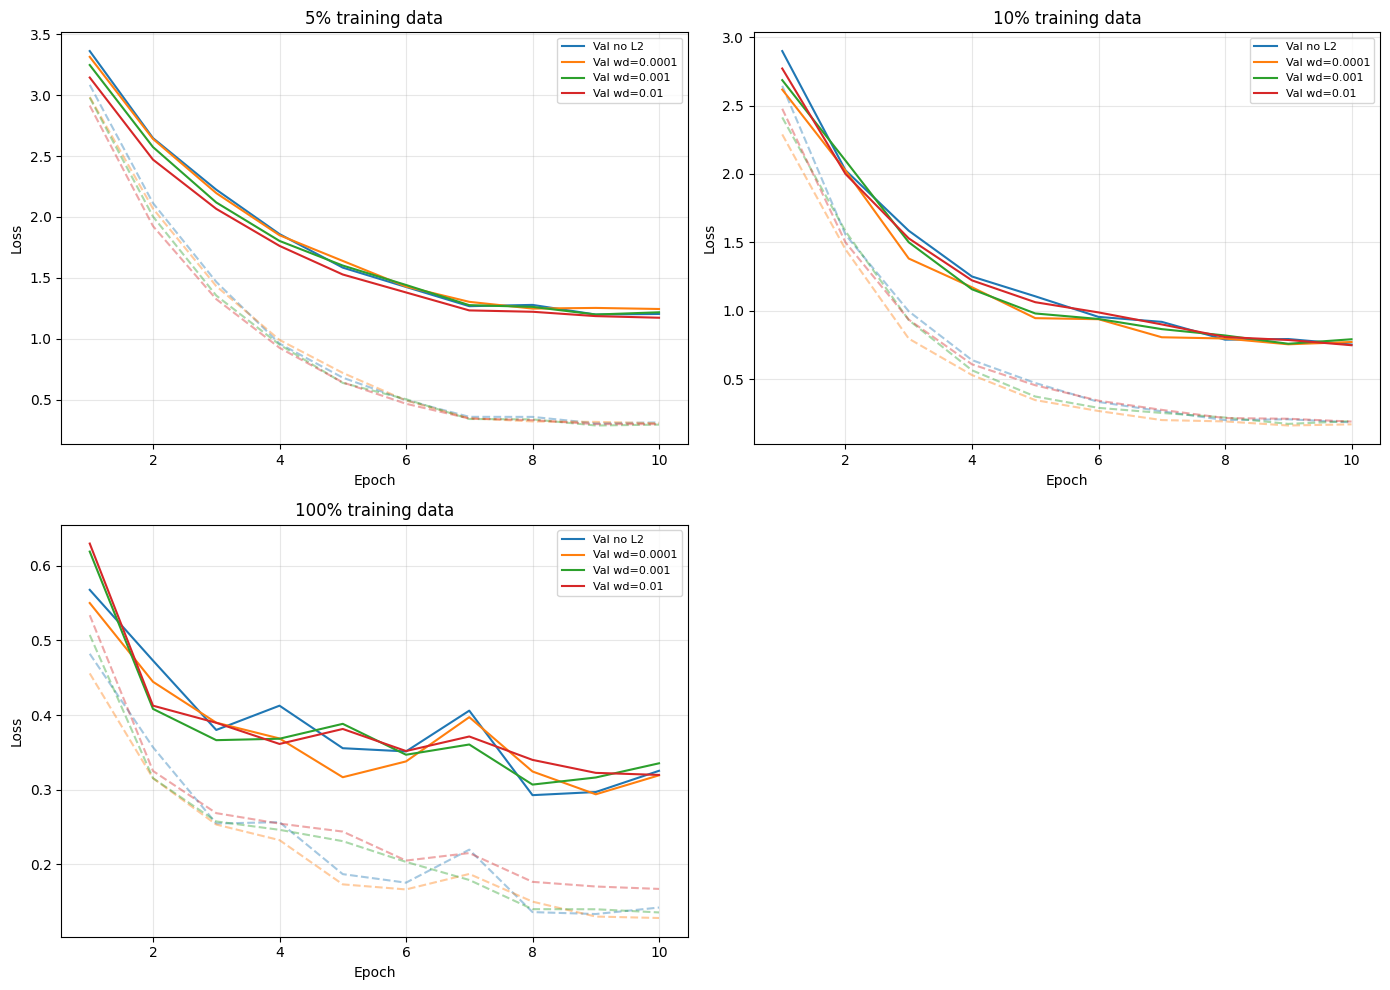

In [ ]:
fractions_unique = sorted(set(r[0] for r in results_l2_base))
wds_unique = sorted(set(r[5] for r in results_l2_base))

# Val accuracy per fraction
ncols = 2
nrows = (len(fractions_unique) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes = axes.flatten()

for ax, frac in zip(axes, fractions_unique):
    for wd in wds_unique:
        run = next(r for r in results_l2_base if r[0] == frac and r[5] == wd)
        _, _, _, train_acc, val_acc, _ = run
        epochs = range(1, len(val_acc) + 1)
        label = 'no L2' if wd == 0 else f'wd={wd:g}'
        line, = ax.plot(epochs, val_acc, linestyle='-', label=f'Val {label}')
        ax.plot(epochs, train_acc, linestyle='--', alpha=0.4, color=line.get_color())
    ax.set_title(f'{int(frac*100)}% training data')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')

for ax in axes[len(fractions_unique):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('../results_limited_data/base_l2_accuracy_per_fraction.png', dpi=150)
plt.show()

# Val loss per fraction
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes = axes.flatten()

for ax, frac in zip(axes, fractions_unique):
    for wd in wds_unique:
        run = next(r for r in results_l2_base if r[0] == frac and r[5] == wd)
        _, train_loss, val_loss, _, _, _ = run
        epochs = range(1, len(val_loss) + 1)
        label = 'no L2' if wd == 0 else f'wd={wd:g}'
        line, = ax.plot(epochs, val_loss, linestyle='-', label=f'Val {label}')
        ax.plot(epochs, train_loss, linestyle='--', alpha=0.4, color=line.get_color())
    ax.set_title(f'{int(frac*100)}% training data')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(fractions_unique):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('../results_limited_data/base_l2_loss_per_fraction.png', dpi=150)
plt.show()

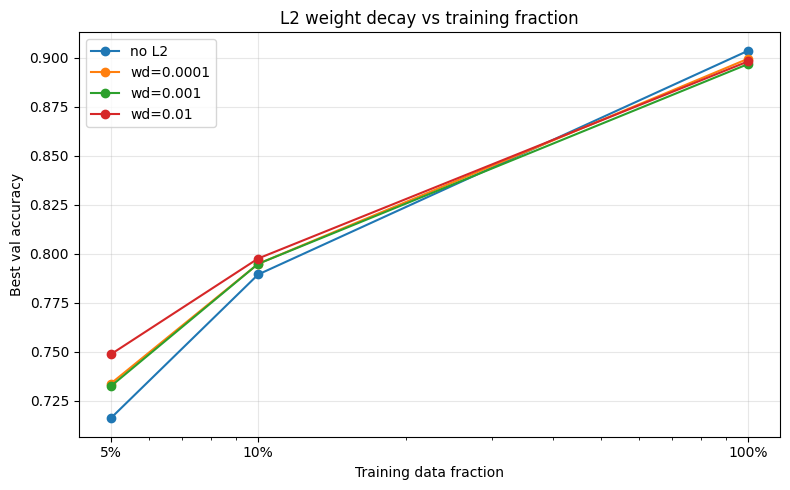

In [ ]:
plt.figure(figsize=(8, 5))
fracs_x = [int(f * 100) for f in fractions_unique]
for wd in wds_unique:
    best = [max(next(r for r in results_l2_base if r[0] == f and r[5] == wd)[4])
            for f in fractions_unique]
    label = 'no L2' if wd == 0 else f'wd={wd:g}'
    plt.plot(fracs_x, best, marker='o', label=label)
plt.xscale('log')
plt.xticks(fracs_x, [f'{p}%' for p in fracs_x])
plt.xlabel('Training data fraction')
plt.ylabel('Best val accuracy')
plt.title('L2 weight decay vs training fraction')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../results_limited_data/base_l2_best_val_acc.png', dpi=150)
plt.show()

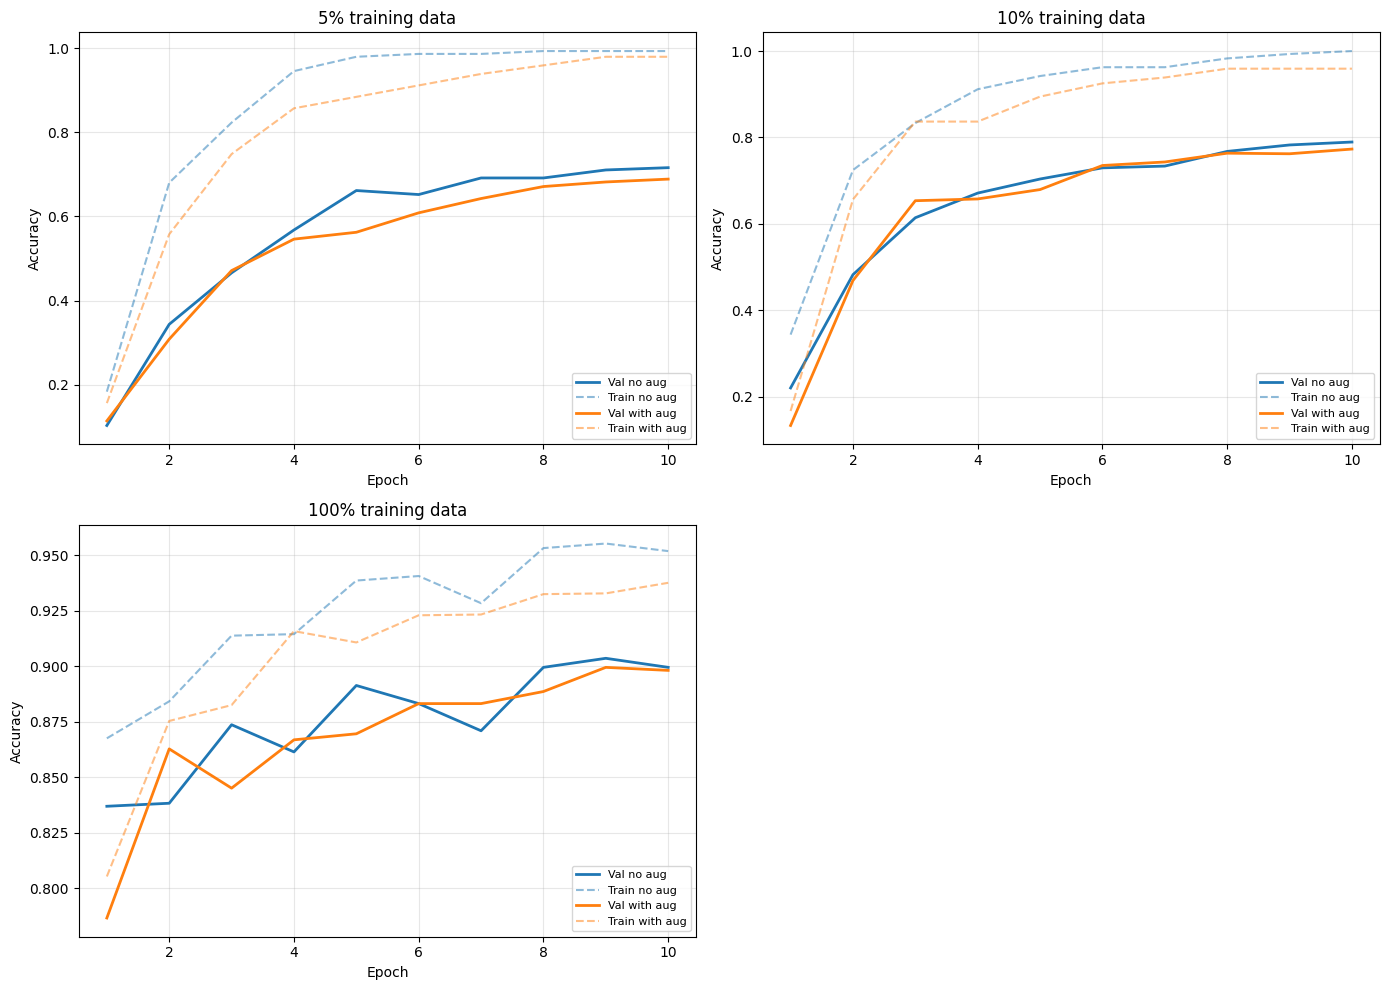

In [ ]:
fractions_unique = sorted(set(r[0] for r in results_l2))

ncols = 2
nrows = (len(fractions_unique) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes = axes.flatten()

for ax, frac in zip(axes, fractions_unique):
    no_aug = next(r for r in results_l2_base if r[0] == frac and r[5] == 0)
    with_aug = next(r for r in results_l2 if r[0] == frac and r[5] == 0)

    epochs = range(1, len(no_aug[4]) + 1)

    line1, = ax.plot(epochs, no_aug[4], linestyle='-', linewidth=2, label='Val no aug')
    ax.plot(epochs, no_aug[3], linestyle='--', alpha=0.5,
            color=line1.get_color(), label='Train no aug')

    line2, = ax.plot(epochs, with_aug[4], linestyle='-', linewidth=2, label='Val with aug')
    ax.plot(epochs, with_aug[3], linestyle='--', alpha=0.5,
            color=line2.get_color(), label='Train with aug')

    ax.set_title(f'{int(frac*100)}% training data')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')

for ax in axes[len(fractions_unique):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('../results_limited_data/aug_vs_noaug.png', dpi=150)
plt.show()

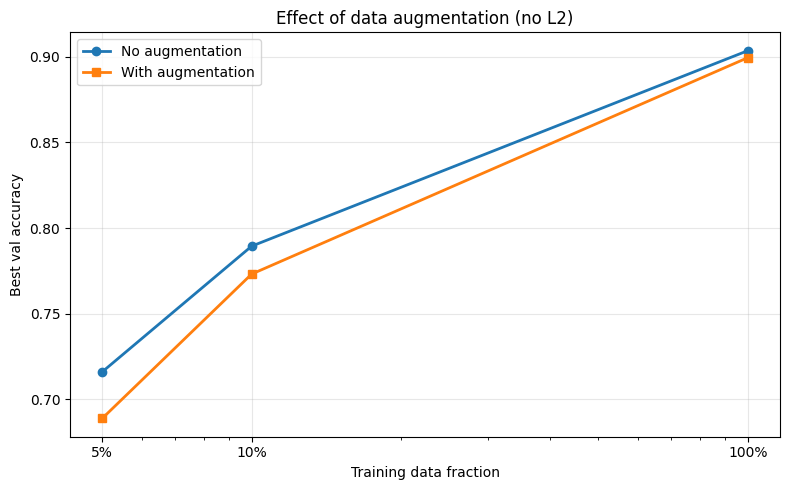

In [ ]:
plt.figure(figsize=(8, 5))
fracs_x = [int(f * 100) for f in fractions_unique]

no_aug_best = [max(next(r for r in results_l2_base if r[0] == f and r[5] == 0)[4])
               for f in fractions_unique]
with_aug_best = [max(next(r for r in results_l2 if r[0] == f and r[5] == 0)[4])
                 for f in fractions_unique]

plt.plot(fracs_x, no_aug_best, marker='o', linewidth=2, label='No augmentation')
plt.plot(fracs_x, with_aug_best, marker='s', linewidth=2, label='With augmentation')

plt.xscale('log')
plt.xticks(fracs_x, [f'{p}%' for p in fracs_x])
plt.xlabel('Training data fraction')
plt.ylabel('Best val accuracy')
plt.title('Effect of data augmentation (no L2)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../results_limited_data/aug_effect.png', dpi=150)
plt.show()